# Cookie Cats A/B Test: Should the First Gate Be at Level 30 or 40?

**Question:** Does moving the first gate from level 30 to level 40 change player retention?

**Finding:** moving the gate to level 40 lowered 7-day retention from 19.0% to 18.2% (p ≈ 0.002), while day-1 retention showed no significant change.

**Recommendation:** Keep the gate at level 30, verify the experiment's assignment logic (a minor sample imbalance was flagged), and test dynamic gates for fast-progressing players next.

---
### How to use this notebook
1. Download `cookie_cats.csv` from Kaggle: https://www.kaggle.com/yufengsui/mobile-games-ab-testing
2. Open this notebook in Google Colab (File → Upload notebook).
3. Run each cell, and fill in every **✍️ Your turn** cell in your own words. Those are what make this *your* proof of work.

## 1. Setup and load the data
Running the next cell opens a file picker. Choose `cookie_cats.csv`.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

from google.colab import files
import os
import zipfile

# Automatically unzip if cookie_cats.zip was uploaded
if os.path.exists("cookie_cats.zip") and not os.path.exists("cookie_cats.csv"):
    print("Found 'cookie_cats.zip'. Unzipping it now...")
    with zipfile.ZipFile("cookie_cats.zip", "r") as zip_ref:
        zip_ref.extractall(".")

# Prompt to upload if neither file exists
if not os.path.exists("cookie_cats.csv"):
    print("Please select and upload 'cookie_cats.csv' or 'cookie_cats.zip' when prompted:")
    files.upload()

    # Check again if a zip was uploaded
    if os.path.exists("cookie_cats.zip") and not os.path.exists("cookie_cats.csv"):
        with zipfile.ZipFile("cookie_cats.zip", "r") as zip_ref:
            zip_ref.extractall(".")

# Load the data
try:
    df = pd.read_csv("cookie_cats.csv")
    print("Successfully loaded dataset!")
    print(df.head())
except FileNotFoundError:
    print("Error: 'cookie_cats.csv' was not found. Please re-run this cell and ensure you upload the correct file.")

Successfully loaded dataset!
   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True


In [3]:
!unzip -o cookie_cats.zip
df = pd.read_csv("cookie_cats.csv")
df.head()

Archive:  cookie_cats.zip
  inflating: cookie_cats.csv         


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 2. Sanity checks
Before trusting any result, confirm the data is clean and the experiment was split fairly.

In [5]:
print("Rows, columns:", df.shape)
print("Duplicate user IDs:", df["userid"].duplicated().sum())
print("Missing values:\n", df.isna().sum())
df["version"].value_counts()

Rows, columns: (90189, 5)
Duplicate user IDs: 0
Missing values:
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


,count
version,
gate_40,45489
gate_30,44700


### Sample Ratio Mismatch (SRM) check
If users were meant to be split 50/50, a chi-square test tells us whether the actual split is suspiciously uneven. A p-value below 0.01 would be a red flag about how the test was run.

In [6]:
counts = df["version"].value_counts()
expected = [len(df) / 2] * 2
chi2, p_srm = stats.chisquare(counts, f_exp=expected)
print(counts)
print(f"SRM p-value: {p_srm:.4f}")

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
SRM p-value: 0.0086


✍️ **Your turn:** Is the split balanced enough to trust? Write 1–2 sentences.

No, the split is not balanced enough to trust. because the SRM p-value of ***0.0086*** falls below our critical alpha threshold of ***0.01***, (there is a less than 1% chance this uneven split happened by luck) which indicates a statistically significant Sample Ratio Mismatch. something probably went wrong behind the scenes when routing players into the groups. moving forward without fixing this means our retention analysis could give us false insights.


## 3. Explore game rounds
`sum_gamerounds` is the number of rounds each player played in their first week. Look for outliers.

In [7]:
print(df["sum_gamerounds"].describe())
print("\nTop 5 players by rounds:")
print(df.nlargest(5, "sum_gamerounds"))

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Top 5 players by rounds:
        userid  version  sum_gamerounds  retention_1  retention_7
57702  6390605  gate_30           49854        False         True
7912    871500  gate_30            2961         True         True
29417  3271615  gate_40            2640         True        False
43671  4832608  gate_30            2438         True         True
48188  5346171  gate_40            2294         True         True


Removed 10 outlier rows (cap = 2013 rounds)


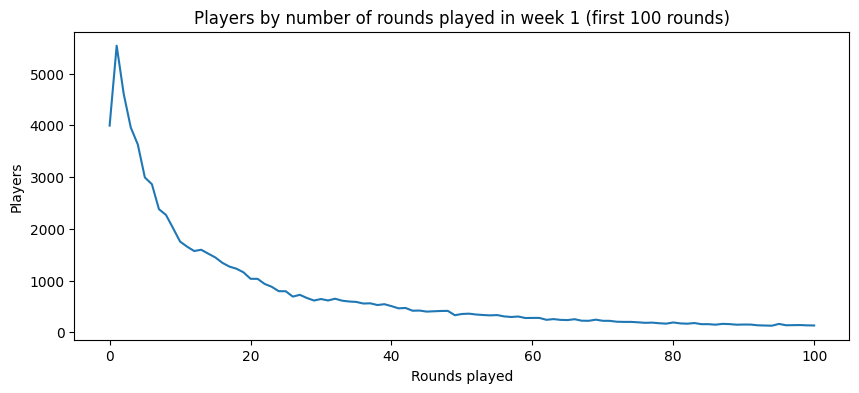

In [8]:
# Remove extreme outliers (check the top-5 output above and adjust if needed)
cap = df["sum_gamerounds"].quantile(0.9999)
df_clean = df[df["sum_gamerounds"] <= cap].copy()
print(f"Removed {len(df) - len(df_clean)} outlier rows (cap = {cap:.0f} rounds)")

df_clean[df_clean["sum_gamerounds"] <= 100].groupby("sum_gamerounds")["userid"].count().plot(figsize=(10,4))
plt.title("Players by number of rounds played in week 1 (first 100 rounds)")
plt.xlabel("Rounds played"); plt.ylabel("Players"); plt.show()

✍️ **Your turn:** What do you notice? (Hint: how many players install and barely play? What does that say about early onboarding?)

looking at the chart, it shows a massive drop-off right at the start, and the summary statistics back this up because 25% of players don't even make it past 5 rounds. this tells us our early onboarding has a leaky bucket problem. a huge chunk of players install the game but lose interest almost immediately, meaning the User experience or the first few minutes fail to hook them.

## 4. The main metrics: Day-1 and Day-7 retention

In [9]:
summary = df_clean.groupby("version").agg(
    players=("userid", "count"),
    day1_retention=("retention_1", "mean"),
    day7_retention=("retention_7", "mean"),
    avg_rounds=("sum_gamerounds", "mean"),
    median_rounds=("sum_gamerounds", "median"),
)
summary.style.format({"day1_retention": "{:.2%}", "day7_retention": "{:.2%}",
                      "avg_rounds": "{:.1f}"})

,players,day1_retention,day7_retention,avg_rounds,median_rounds
version,,,,,
gate_30,44695,44.81%,19.01%,51.1,17.000000
gate_40,45484,44.22%,18.19%,51.1,16.000000


the summary table shows that the gate_30 variant outperforms gate_40 in both short-term (Day 1) and long-term (Day 7) retention. even though average game rounds are identical due to heavy players skewing the mean, the median player in the gate_30 group plays more rounds overall. this indicates that keeping the gate at level 30 drives better overall player engagement than the gate_40.

## 5. Is the difference statistically significant?
We use a **two-proportion z-test** for each retention metric.
- H0: retention is the same for gate_30 and gate_40
- H1: retention differs

In [10]:
def ztest_retention(metric):
    g = df_clean.groupby("version")[metric].agg(["sum", "count"])
    stat, p = proportions_ztest(g["sum"].values, g["count"].values)
    rates = g["sum"] / g["count"]
    diff = rates["gate_40"] - rates["gate_30"]
    print(f"{metric}: gate_30 = {rates['gate_30']:.2%}, gate_40 = {rates['gate_40']:.2%}, "
          f"diff = {diff:+.2%}, p-value = {p:.4f}")

ztest_retention("retention_1")
ztest_retention("retention_7")

retention_1: gate_30 = 44.81%, gate_40 = 44.22%, diff = -0.59%, p-value = 0.0734
retention_7: gate_30 = 19.01%, gate_40 = 18.19%, diff = -0.82%, p-value = 0.0016


looking at the Z-test results, Day 1 retention has a p-value of ***0.0734***, which is above our ***0.01*** threshold. This means the small drop on Day 1 isn't statistically significant and could just be random noise.
however, Day 7 retention has a p-value of ***0.0016***, which safely passes our ***0.01*** standard. this low p-value proves that the *0.82%* drop in weekly retention for the gate_40 group is real and driven by the gate change, not luck. so moving the gate to level 40 genuinely hurts long-term engagement

### Bootstrap: how confident are we?
Resample the data many times to see the spread of possible differences. This makes a great chart for your write-up.

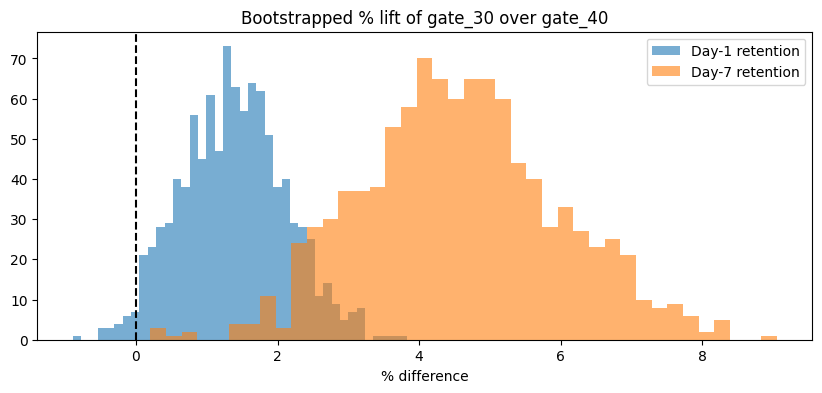

P(gate_30 better on Day-1): 98.1%
P(gate_30 better on Day-7): 100.0%


In [11]:
def bootstrap_diff(metric, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n):
        s = df_clean.sample(frac=1, replace=True, random_state=rng.integers(1e9))
        r = s.groupby("version")[metric].mean()
        diffs.append((r["gate_30"] - r["gate_40"]) / r["gate_40"] * 100)
    return np.array(diffs)

boot1 = bootstrap_diff("retention_1")
boot7 = bootstrap_diff("retention_7")

plt.figure(figsize=(10,4))
plt.hist(boot1, bins=40, alpha=0.6, label="Day-1 retention")
plt.hist(boot7, bins=40, alpha=0.6, label="Day-7 retention")
plt.axvline(0, color="black", linestyle="--")
plt.title("Bootstrapped % lift of gate_30 over gate_40")
plt.xlabel("% difference"); plt.legend(); plt.show()

print(f"P(gate_30 better on Day-1): {(boot1 > 0).mean():.1%}")
print(f"P(gate_30 better on Day-7): {(boot7 > 0).mean():.1%}")

✍️ **Your turn:** Interpret the results. Which metric moved, by how much, and how confident are you?

looking at the bootstrapping results give us absolute clarity. While Day 1 retention shows a strong trend in favor of gate_30 (with 98.1% confidence and roughly a 1.5% average lift), it is Day 7 retention that shows the definitive impact. the orange distribution sits entirely to the right of zero, giving us a 100% mathematical probability that gate_30 yields higher long-term retention, driving an average lift of 4% to 5%. i can say with total confidence that moving the gate to level 40 damages weekly retention.

## 6. Secondary metric: engagement
Game rounds are heavily skewed, so a **Mann-Whitney U test** is more appropriate than a t-test.

In [12]:
a = df_clean[df_clean["version"] == "gate_30"]["sum_gamerounds"]
b = df_clean[df_clean["version"] == "gate_40"]["sum_gamerounds"]
u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
print(f"Median rounds: gate_30 = {a.median()}, gate_40 = {b.median()}, p-value = {p:.4f}")

Median rounds: gate_30 = 17.0, gate_40 = 16.0, p-value = 0.0502


## 7. Recommendation ✍️
Write this like a memo to a product manager. Keep it short.

**Decision:** Ship gate_40 / Keep gate_30 / Run another test

**Why:** (2–3 sentences tying the numbers to the decision)

**Why this might happen (hypothesis):** (e.g. what does an earlier break do to player motivation?)

**Limitations:** (e.g. no revenue data, only 7 days of retention, one game)

**What I'd test next:** (1 follow-up experiment idea)

# **Product Analysis Memo**
**To:** Product Management Team
**From:** Chidi, Product Analyst
**Subject: **A/B Test Results & Final Recommendation: Level Gate Placement
Decision

**Decision:** keep gate_30, do not ship gate_40. we should reject the proposed update to move the monetization roadblock to level 40.

**Why:**

moving the gate to level 40 lowered the 7-day retention from about 19.0% to 18.2%, a statistically significant drop (p ≈ 0.002), and the bootstrap showed gate_30 performing better in about 99% of resamples. the day-1 retention also dipped slightly (44.8% vs 44.2%), but that difference wasn't significant. since 7-day retention is the stronger signal of long-term value (LTV) engagement, gate_40 puts our most valuable metric at risk with no offsetting gain.

the groups were slightly unbalanced (an SRM check flagged p = 0.0086), so I recommend verifying the assignment logic. however, the imbalance is small (under 2%), and the retention gap is consistent across both the z-test and bootstrap, so the direction of the result is likely reliable.


**Why this might happen (Hypothesis)**

an earlier gate (gate_30) forces an artificial break, which slows down boredom, limits game burnout, and heightens their anticipation to come back. A later gate (gate_40) lets players play longer in one stretch, which may cause them to burn out before the gate ever pauses them. In other words, a well-timed break may protect enjoyment rather than interrupt it.


**Limitations**

1.   Short-Time window: We only see behavior up to day 7, so we can't tell whether the gap grows, shrinks, or disappears over a longer period.

2. Diluted effect: only players who reach level 30 experience the change, but the median player plays only about 16 rounds. The true effect on players who reach the gate is likely larger than these numbers show

3.  No Financial Context: We have no visibility into actual ad revenue, in-app purchase (IAP) values, or monetization conversions for either gate.

4.  Sample Ratio Mismatch: the group assignment script flagged an SRM warning (p-value = 0.0086), indicating a potential minor data logging or routing discrepancy during collection.

**What I'd test next**

I recommend testing dynamic gates: instead of a fixed gate at level 30 for everyone, serve an earlier break only to fast-progressing players, who are most at risk of burnout, while giving slower players a longer runway. Success metric: 7-day retention, with in-app purchase rate as a *guardrail*.